In [1]:
#1. OBSERVAMOS LAS DIMENSIONES DE LOS DATOS
import h5py as h5
import numpy as np
import time
import pandas as pd
import os
import json
# 1. Configuración de la ruta
ruta_maestra = r"C:\Users\MSI\Downloads\Proyecto_Fluidos_AI\datos_procesados\process_data.h5"

ruta_carpeta_guardar= r"C:\Users\MSI\Downloads\Proyecto_Fluidos_AI\datos_procesados\runtransformertesteo"
# Crear la carpeta si no existe
os.makedirs(ruta_carpeta_guardar, exist_ok=True)

with h5.File(ruta_maestra, 'r') as f:
    # Leemos las dimensiones de las tres componentes
    grupo = f['data_analisis']
    u_shape = grupo['u_fluc'].shape
    v_shape = grupo['v_fluc'].shape
    w_shape = grupo['w_fluc'].shape

# Verificación de seguridad: las 3 matrices deben ser idénticas en tamaño
assert u_shape == v_shape == w_shape, "¡Error crítico! Las dimensiones de U, V y W no coinciden."

num_tiempos = u_shape[0]
dim_y = u_shape[1] #number of lines of probes
dim_z = u_shape[2]
total_puntos_espaciales = dim_y * dim_z

print("--- ESTADÍSTICAS DEL DATASET MULTICANAL ---")
print(f"Total de instantes de tiempo: {num_tiempos}")
print(f"Malla espacial: {dim_y} x {dim_z} = {total_puntos_espaciales} puntos")
print(f"Canales de velocidad: 3 (U, V, W)")
print(f"Total de datos numéricos a procesar: {num_tiempos * total_puntos_espaciales * 3:,}")

# 2. CÁLCULO DE DIVISIONES (Splits temporales)
# Primero separamos el 20% para el examen final (test/resultados)
indice_test = int(num_tiempos * 0.8)

# Del 80% restante, separamos otro 20% para validación (0.8 * 0.8 = 0.64)
indice_val = int(indice_test * 0.8)

salto = 50

print("\n--- REPARTO DEL TIEMPO ---")
print(f"1. Entrenamiento (64%): Pasos 0 al {indice_val}")
print(f"2. Validación    (16%): Pasos {indice_val} al {indice_test}")
print(f"3. Resultados    (20%): Pasos {indice_test} al {num_tiempos}")

--- ESTADÍSTICAS DEL DATASET MULTICANAL ---
Total de instantes de tiempo: 106000
Malla espacial: 7 x 288 = 2016 puntos
Canales de velocidad: 3 (U, V, W)
Total de datos numéricos a procesar: 641,088,000

--- REPARTO DEL TIEMPO ---
1. Entrenamiento (64%): Pasos 0 al 67840
2. Validación    (16%): Pasos 67840 al 84800
3. Resultados    (20%): Pasos 84800 al 106000


In [2]:
# ==========================================
# 2. PREPARACIÓN DE LOS DATOS PARA EL MODELO (SPLIT TEMPORAL 64/16/20)
# ==========================================
import torch
import h5py as h5  # Corregido el alias de h5py
import numpy as np
from torch.utils.data import TensorDataset, DataLoader 
import os
import gc  # Importamos el recolector de basura

def obtener_o_crear_datasets(ruta_maestra, train_pt, val_pt, test_pt, stats_pt, linea_idy):
    """
    Comprueba si existen los archivos procesados. 
    Si existen, los carga. Si no, ejecuta la lógica temporal (64/16/20) y los guarda.
    """
    
    # 1. Comprobar si TODOS los archivos ya existen en el disco
    if os.path.exists(train_pt) and os.path.exists(val_pt) and os.path.exists(test_pt) and os.path.exists(stats_pt):
        print(f"📦 Archivos detectados. Cargando datasets desde el disco...")
        train_ds = torch.load(train_pt, weights_only=False)
        val_ds = torch.load(val_pt, weights_only=False)
        test_ds = torch.load(test_pt, weights_only=False)
        stats = torch.load(stats_pt, weights_only=False)
        return train_ds, val_ds, test_ds, stats

    else:
        print("⚙️ Archivos no encontrados. Generando datasets desde cero...")
        with h5.File(ruta_maestra, 'r') as f:
            matriz_base = f['data_analisis']['u_fluc'][:, linea_idy, :]  # Forma: (106000, 288)

            # Empaquetamos espacialmente para tener los 5760 puntos
            chunk_size = 16500 
            num_chunks = len(matriz_base) // chunk_size 
            matriz_recortada = matriz_base[:num_chunks * chunk_size, :]
            
            trozos = []
            for i in range(num_chunks):
                inicio = i * chunk_size
                fin = (i + 1) * chunk_size
                pedazo = matriz_recortada[inicio:fin, :]
                trozos.append(pedazo)

            # matriz_final pasará a ser (5050, 5760)
            matriz_final_raw = np.hstack(trozos)
            print(f"-> Forma de la matriz temporal/espacial: {matriz_final_raw.shape}")

        # ==========================================
        # 5. DIVISIÓN CRONOLÓGICA (EL HACHAZO TEMPORAL: 64% / 16% / 20%)
        # ==========================================
        total_pasos = matriz_final_raw.shape[0]  # 5050 pasos de tiempo
        
        corte_train = int(total_pasos * 0.64)          # Instante 3232
        corte_val = int(total_pasos * (0.64 + 0.16))   # Instante 4040

        # Cortamos el pan en estricto orden cronológico
        matriz_train_raw = matriz_final_raw[:corte_train, :]       # Pasado lejano
        matriz_val_raw   = matriz_final_raw[corte_train:corte_val, :]  # Pasado reciente
        matriz_test_raw  = matriz_final_raw[corte_val:, :]         # Futuro

        print(f"-> Train (64%): {matriz_train_raw.shape[0]} instantes")
        print(f"-> Val   (16%): {matriz_val_raw.shape[0]} instantes")
        print(f"-> Test  (20%): {matriz_test_raw.shape[0]} instantes")

        # Normalizamos usando SÓLO los datos de Train (Evita fuga del futuro al pasado)
        media_X = np.mean(matriz_train_raw)
        std_X = np.std(matriz_train_raw)

        stats = {'media': media_X, 'std': std_X}

        matriz_train = np.float32((matriz_train_raw - media_X) / std_X)
        matriz_val   = np.float32((matriz_val_raw - media_X) / std_X)
        matriz_test  = np.float32((matriz_test_raw - media_X) / std_X)

        # TRUCO: Borramos las variables gigantes y vaciamos RAM
        del matriz_final_raw, matriz_train_raw, matriz_val_raw, matriz_test_raw, trozos, matriz_recortada
        gc.collect()

        # ==========================================
        # 6. CREACIÓN DE VENTANAS DESLIZANTES
        # ==========================================
        seq_x = 300  # Historia pasada
        seq_y = 50   # Futuro a predecir
        salto = 50   # Zancada

        def crear_ventanas(matriz, lookback, predict, stride):
            X_lista, y_lista = [], []
            num_tiempos = matriz.shape[0]
            
            for i in range(0, num_tiempos - lookback - predict + 1, stride):
                bloque_x = matriz[i : i + lookback, :]       
                bloque_y = matriz[i + lookback : i + lookback + predict, :] 
                
                # Transponemos para que las columnas sean filas (ejemplos espaciales)
                X_lista.append(bloque_x.T)
                y_lista.append(bloque_y.T)
            
            return np.vstack(X_lista), np.vstack(y_lista)

        print("\nGenerando ventanas deslizantes...")
        X_train_np, y_train_np = crear_ventanas(matriz_train, seq_x, seq_y, salto)
        X_val_np, y_val_np     = crear_ventanas(matriz_val, seq_x, seq_y, salto)
        X_test_np, y_test_np   = crear_ventanas(matriz_test, seq_x, seq_y, salto)

        print(f"-> Ejemplos Train: {X_train_np.shape[0]}")
        print(f"-> Ejemplos Val:   {X_val_np.shape[0]}")
        print(f"-> Ejemplos Test:  {X_test_np.shape[0]}")

        # ==========================================
        # 7. CONVERSIÓN A TENSORES Y GUARDADO
        # ==========================================
        train_features = torch.from_numpy(X_train_np).unsqueeze(-1)
        val_features   = torch.from_numpy(X_val_np).unsqueeze(-1)
        test_features  = torch.from_numpy(X_test_np).unsqueeze(-1)

        train_labels = torch.from_numpy(y_train_np).unsqueeze(-1)
        val_labels   = torch.from_numpy(y_val_np).unsqueeze(-1)
        test_labels  = torch.from_numpy(y_test_np).unsqueeze(-1)

        del X_train_np, y_train_np, X_val_np, y_val_np, X_test_np, y_test_np
        gc.collect()

        train_dataset = TensorDataset(train_features, train_labels)
        val_dataset   = TensorDataset(val_features, val_labels)
        test_dataset  = TensorDataset(test_features, test_labels)

        torch.save(train_dataset, train_pt)
        torch.save(val_dataset, val_pt)
        torch.save(test_dataset, test_pt)
        torch.save(stats, stats_pt)

        return train_dataset, val_dataset, test_dataset, stats

# ==========================================
# --- MODO DE USO ---
# ==========================================
linea_idy = 2

# Nombres de los archivos (Les he puesto 'split' para que no pise los viejos)
f_train = 'train_dataset_tf_split.pt'
f_val   = 'val_dataset_tf_split.pt'
f_test  = 'test_dataset_tf_split.pt'
f_stats = 'norm_stats_tf_split.pt'

# 1. Llamamos a la función (ahora devuelve 4 cosas)
train_dataset, val_dataset, test_dataset, stats_norm = obtener_o_crear_datasets(
    ruta_maestra, f_train, f_val, f_test, f_stats, linea_idy
)

# 2. Creamos los Loaders
batch_size_gpu = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size_gpu, shuffle=True, drop_last=False, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size_gpu, shuffle=False, drop_last=False, num_workers=0, pin_memory=True)

# Opcional: Loader de test (para evaluarlo al final de todo el proyecto)
test_loader  = DataLoader(test_dataset, batch_size=batch_size_gpu, shuffle=False, drop_last=False, num_workers=0, pin_memory=True)

print("\n✅ ¡Datasets listos y cargados en memoria!")

📦 Archivos detectados. Cargando datasets desde el disco...

✅ ¡Datasets listos y cargados en memoria!


In [3]:
# ==========================================
# 3. DEFINIMOS NUESTRO MODELO TRANSFORMER (DROPOUT + SEQ 300)
# ==========================================

import torch
import torch.nn as nn

class MultiHeadEasyAttention(nn.Module):
    # 🚨 CAMBIO 1: Añadimos 'dropout_rate' a los argumentos de inicialización
    def __init__(self, seq_len, input_dim, d_model, num_heads=4, dropout_rate=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model debe ser divisible por num_heads"
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        
        # Tensor \alpha para múltiples cabezas: (h, p, p)
        self.alpha = nn.Parameter(torch.empty(num_heads, seq_len, seq_len))
        nn.init.xavier_uniform_(self.alpha)
        
        # Proyección compartida W_V para todas las cabezas
        self.W_v = nn.Linear(input_dim, d_model, bias=False)
        
        # 🚨 CAMBIO 2: Definimos la capa de Dropout específica para la matriz alfa
        self.dropout_alpha = nn.Dropout(dropout_rate)

    def forward(self, x):
        b, p, _ = x.size() # b=Batch, p=seq_len
        
        # 1. Proyectar valores: (Batch, seq_len, d_model)
        V = self.W_v(x)
        
        # 2. Separar en múltiples cabezas: (Batch, seq_len, num_heads, head_dim)
        V = V.view(b, p, self.num_heads, self.head_dim)
        # Transponer para emparejar con alpha: (Batch, num_heads, seq_len, head_dim)
        V = V.permute(0, 2, 1, 3)
        
        # 🚨 CAMBIO 3: "Apagamos" conexiones aleatorias en la matriz estática ANTES de multiplicar
        alpha_con_dropout = self.dropout_alpha(self.alpha)
        
        # 3. Multiplicar cada cabeza de \alpha (rota por el dropout) con su bloque V
        out = torch.einsum('hij,bhjd->bhid', alpha_con_dropout, V)
        
        # 4. Concatenar las cabezas de vuelta al tamaño d_model
        out = out.permute(0, 2, 1, 3).contiguous().view(b, p, -1)
        return out
    

class EasyTransformerBlock(nn.Module):
    def __init__(self, seq_len, d_model=64, num_heads=4, dropout_rate=0.1):
        super().__init__()
        
        # 🚨 CAMBIO 4: Le pasamos el 'dropout_rate' a MultiHeadEasyAttention
        self.attention = MultiHeadEasyAttention(seq_len, d_model, d_model, num_heads, dropout_rate)
        
        self.norm1 = nn.LayerNorm(d_model)
        
        # DROPOUT Después de la atención
        self.dropout1 = nn.Dropout(dropout_rate)
        
        expansion_factor = 4
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_model * expansion_factor), 
            nn.ReLU(),
            # DROPOUT Dentro del bloque Feed Forward
            nn.Dropout(dropout_rate),
            nn.Linear(d_model * expansion_factor, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)
        
        # DROPOUT Después del Feed Forward
        self.dropout2 = nn.Dropout(dropout_rate)

    def forward(self, x):
        # Bloque 1: Atención + Dropout + Residual + Normalización
        attn_out = self.attention(x)
        attn_out = self.dropout1(attn_out) 
        x = self.norm1(x + attn_out)
        
        # Bloque 2: Feed Forward + Dropout + Residual + Normalización
        ff_out = self.feed_forward(x)
        ff_out = self.dropout2(ff_out)     
        x = self.norm2(x + ff_out)
        return x


class EasyFluidPredictor(nn.Module):
    # 🚨 CORRECCIÓN: seq_len=300 por defecto para cuadrar con los datasets
    def __init__(self, seq_len=300, pred_len=50, input_dim=1, d_model=64, num_heads=4, dropout_rate=0.1):
        super().__init__()
        self.input_dim = input_dim
        
        self.input_proj = nn.Linear(input_dim, d_model)
        self.input_dropout = nn.Dropout(dropout_rate)
        
        self.easy_transformer = EasyTransformerBlock(seq_len, d_model, num_heads, dropout_rate)
        
        self.temporal_proj = nn.Linear(seq_len, pred_len)  
        self.final_proj = nn.Linear(d_model, input_dim)     

    def forward(self, x):
        # Entrada original: (Batch, 300, 1)
        x = self.input_proj(x)          # Forma: (Batch, 300, 64)
        x = self.input_dropout(x)       
        x = self.easy_transformer(x)    # Forma: (Batch, 300, 64)
        
        # Pasamos de (Batch, Tiempo, Canales) a (Batch, Canales, Tiempo)
        x = x.permute(0, 2, 1)          # Forma: (Batch, 64, 300)
        
        # Transformamos los 300 instantes del pasado en los 50 del futuro de golpe
        x = self.temporal_proj(x)       # Forma: (Batch, 64, 50)
        
        # Devolvemos las dimensiones a su orden natural: (Batch, Tiempo_Futuro, Canales)
        x = x.permute(0, 2, 1)          # Forma: (Batch, 50, 64)
        
        # Proyectamos los 64 canales ocultos a tu variable física u (1 canal)
        out = self.final_proj(x)        # Forma final: (Batch, 50, 1)
        
        return out

In [4]:
#4. ENTRENAMOS NUESTRA RED NEURONAL
# ==========================================
# 1. CONFIGURACIÓN DEL HARDWARE
# ==========================================

# Detectar si hay Tarjeta Gráfica (GPU) disponible. Si no, usará la CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en el dispositivo: {device}")


# 🚨 AUTODETECCIÓN DE DIMENSIONES 🚨
# train_dataset[0] devuelve la primera tupla (X, Y)
ejemplo_x, ejemplo_y = train_dataset[0]

num_heads = 2  # Puedes ajustar este número según la capacidad de tu GPU y la complejidad que quieras

d_model = 64  # Dimensión interna del modelo (puedes ajustar este número para hacerlo más pequeño o más grande)

input_dim = ejemplo_x.shape[1]  # Cada punto espacial es un canal de entrada

pred_len = ejemplo_y.shape[0]  # Número de pasos futuros a predecir

seq_len = ejemplo_x.shape[0]  # Número de pasos pasados que el modelo usará para predecir

lr=0.0001  # Tasa de aprendizaje para el optimizador



modelo = EasyFluidPredictor(seq_len=seq_len, pred_len=pred_len, input_dim=input_dim, d_model=d_model, num_heads=num_heads, dropout_rate=0.3)

# Movemos el modelo a la tarjeta gráfica (o lo dejamos en CPU)
modelo.to(device)


criterio = torch.nn.MSELoss()

# --- 🚀 NUEVO: CONFIGURACIÓN DE PÉRDIDA POR GRADIENTE ---
# 0.1 o 0.2 suele ser el "punto dulce" para empezar. 
# Si notas que la línea roja se vuelve demasiado caótica o "nerviosa", baja este valor a 0.05.
peso_gradiente = 0.1

optimizador = torch.optim.Adam(modelo.parameters(), lr=lr, weight_decay=1e-4)






# ==========================================
# 2. PARÁMETROS DEL ENTRENAMIENTO
# ==========================================
epocas = 150  # Número de veces que la IA verá TODO el dataset completo
tek=time.time()


historial_train_loss = []
historial_val_loss = []
#Creamos para guadar el mejor modelo basado en la pérdida de validación
best_val_loss = float('inf')  # Empezamos con "infinito" para que cualquier pérdida sea menor
ruta_mejor_modelo = ruta_carpeta_guardar+'/mejor_modelo_ia_transformer_eas.pt'

print("\n🚀 ¡Iniciando el entrenamiento de la Red Neuronal!")
print("-" * 60)

# ==========================================
# 3. EL BUCLE PRINCIPAL
# ==========================================
for epoca in range(epocas):
    print(f"\n📊 Época {epoca+1}/{epocas}")
    tic = time.time()
    
    # --- FASE DE ENTRENAMIENTO ---
    modelo.train()  # Ponemos el modelo en modo "aprender"
    train_loss_acumulada = 0.0
    
    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        print(f"   Procesando lote {batch_idx+1}/{len(train_loader)}", end='\r')
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        # a) Reiniciamos los gradientes
        optimizador.zero_grad()
        
        # b) Pasada hacia adelante (Forward)
        predicciones = modelo(x_batch)
        
        # --- 🚀 c) MODIFICADO: CÁLCULO DEL ERROR COMBINADO ---
        # 1. Pérdida base (Píxel a píxel)
        loss_base = criterio(predicciones, y_batch)
        
        # 2. Pérdida por gradiente temporal (Diferencias entre instantes consecutivos)
        # predicciones forma: (Batch, 50, 1). Restamos el paso t al paso t+1
        diff_pred = predicciones[:, 1:, :] - predicciones[:, :-1, :]
        diff_real = y_batch[:, 1:, :] - y_batch[:, :-1, :]
        loss_gradient = torch.mean(torch.abs(diff_pred - diff_real)) # Usamos MAE para los saltos
        
        # 3. Suma total
        loss = loss_base + (peso_gradiente * loss_gradient)
        
        # d) Pasada hacia atrás (Backward)
        loss.backward()
        
        # e) Actualizamos los pesos
        optimizador.step()
        
        train_loss_acumulada += loss.item()

        
    # Calculamos el error medio de esta época
    avg_train_loss = train_loss_acumulada / len(train_loader)
    historial_train_loss.append(avg_train_loss)
    
    
    # --- FASE DE VALIDACIÓN ---
    modelo.eval()  # Modo examen
    val_loss_acumulada = 0.0
    
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val = x_val.to(device)
            y_val = y_val.to(device)
            
            predicciones_val = modelo(x_val)
            
            # --- 🚀 MODIFICADO: VALIDACIÓN CON LA MISMA MÉTRICA ---
            loss_base_val = criterio(predicciones_val, y_val)
            diff_pred_val = predicciones_val[:, 1:, :] - predicciones_val[:, :-1, :]
            diff_real_val = y_val[:, 1:, :] - y_val[:, :-1, :]
            loss_gradient_val = torch.mean(torch.abs(diff_pred_val - diff_real_val))
            
            loss_val = loss_base_val + (peso_gradiente * loss_gradient_val)
            val_loss_acumulada += loss_val.item()
            
    # Calculamos el error medio del examen
    avg_val_loss = val_loss_acumulada / len(val_loader)
    historial_val_loss.append(avg_val_loss)
    toc = time.time()

    # --- GUARDADO DEL MEJOR MODELO ---
    if avg_val_loss < best_val_loss:
        print(f"⭐ ¡Nuevo récord! La pérdida bajó de {best_val_loss:.6f} a {avg_val_loss:.6f}. Guardando...")
        
        best_val_loss = avg_val_loss
        
        checkpoint = {
            'epoch': epoca,
            'model_state_dict': modelo.state_dict(),
            'optimizer_state_dict': optimizador.state_dict(),
            'loss': best_val_loss,
            'stats': stats_norm 
        }
        torch.save(checkpoint, ruta_mejor_modelo)

    # Imprimimos el progreso al final de cada época
    print(f"Época [{epoca+1:02d}/{epocas}] | Train Loss (Compuesta): {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")
    print(f"Tiempo de la época: {toc - tic:.2f} segundos")

print("-" * 60)
print("✅ ¡Entrenamiento completado!")
tac=time.time()

Entrenando en el dispositivo: cuda

🚀 ¡Iniciando el entrenamiento de la Red Neuronal!
------------------------------------------------------------

📊 Época 1/150
⭐ ¡Nuevo récord! La pérdida bajó de inf a 0.317852. Guardando...
Época [01/150] | Train Loss (Compuesta): 0.346339 | Val Loss: 0.317852
Tiempo de la época: 69.65 segundos

📊 Época 2/150
⭐ ¡Nuevo récord! La pérdida bajó de 0.317852 a 0.311055. Guardando...
Época [02/150] | Train Loss (Compuesta): 0.298063 | Val Loss: 0.311055
Tiempo de la época: 69.92 segundos

📊 Época 3/150
Época [03/150] | Train Loss (Compuesta): 0.290814 | Val Loss: 0.325997
Tiempo de la época: 69.52 segundos

📊 Época 4/150
⭐ ¡Nuevo récord! La pérdida bajó de 0.311055 a 0.296644. Guardando...
Época [04/150] | Train Loss (Compuesta): 0.287040 | Val Loss: 0.296644
Tiempo de la época: 69.18 segundos

📊 Época 5/150
Época [05/150] | Train Loss (Compuesta): 0.284519 | Val Loss: 0.300097
Tiempo de la época: 69.14 segundos

📊 Época 6/150
Época [06/150] | Train Loss 

KeyboardInterrupt: 

In [ ]:
# ==========================================
# 5. GUARDADO DE METADATOS Y RESULTADOS (JSON)
# ==========================================
import json
import time

# Creamos el diccionario adaptado a la arquitectura Transformer
metadata = {}

# 1. Arquitectura del Transformer (Los "músculos" del modelo)
metadata['model_type'] = "Easy Attention Transformer"
metadata['input_dim'] = input_dim         # Dimensión de entrada (velocidad u)
metadata['seq_len'] = seq_len             # Ventana de pasado (lookback)
metadata['pred_len'] = pred_len             # Ventana de futuro (prediction)
metadata['d_model'] = d_model              # Espacio latente interno
metadata['num_heads'] = num_heads             # Número de cabezas de atención

# 2. Hiperparámetros de entrenamiento
metadata['learning_rate'] = lr    # El LR que pusimos en el Adam
metadata['epochs_planned'] = epocas   # Total de épocas solicitadas
metadata['peso_gradiente'] = peso_gradiente  # 🚨 NUEVO: Peso de la función de pérdida física
metadata['dropout_rate'] = 0.1               # 🚨 NUEVO: Tasa de Dropout usada (cámbialo si usaste otro)

# 3. Estadísticas de rendimiento (El "marcador")
metadata['best_val_loss'] = best_val_loss
metadata['salto_ventana_deslizante'] = 50  # 🚨 CORREGIDO: Lo ponemos a mano (50) para evitar error de variable
metadata['train_time_seconds'] = tac - tek
metadata['train_time_minutes'] = (tac - tek) / 60
metadata['date_time'] = time.strftime("%Y-%m-%d %H:%M:%S")

# 4. Información del Dataset y Hardware
metadata['linea_idy'] = linea_idy      # La sonda/línea analizada (ej: 2)
metadata['num_train_samples'] = len(train_loader.dataset)
metadata['num_val_samples'] = len(val_loader.dataset)
metadata['num_test_samples'] = len(test_loader.dataset) # 🚨 NUEVO: Añadimos las muestras de test
metadata['gpu_name'] = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"

# 5. Estadísticas de Normalización (¡Crucial para usar el modelo después!)
# Guardamos media y std para poder des-normalizar predicciones sin cargar el .pt
metadata['norm_stats'] = {
    'media': float(stats_norm['media']),
    'std': float(stats_norm['std'])
}

# Guardar el diccionario en un archivo JSON bien formateado
ruta_json = ruta_carpeta_guardar + '/hyperparams_transformer.json'

with open(ruta_json, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print(f"✅ Metadatos guardados correctamente en: {ruta_json}")

In [ ]:
# ==========================================
# 6. VISUALIZACIÓN DE RESULTADOS
# ==========================================
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
import numpy as np
import pandas as pd

# ==========================================
# DIBUJAMOS LA GRÁFICA
# ==========================================
plt.figure(figsize=(10, 6))

# Eje X: Número de épocas (de 1 a N)
epocas_x = range(1, len(historial_train_loss) + 1)

# Convertimos en arrays
historial_val_loss_np = np.array(historial_val_loss)
epocas_x_np = np.array(epocas_x)

# Trazamos las curvas de la IA
plt.semilogy(epocas_x, historial_train_loss, 'b-o', label='Train Loss (Entrenamiento)', linewidth=2)
plt.semilogy(epocas_x, historial_val_loss, 'g-s', label='Val Loss (Validación)', linewidth=2)

# Marcamos el mejor modelo
mejor_epoca = epocas_x[historial_val_loss_np.argmin()]
mejor_loss = historial_val_loss_np.min()
plt.semilogy(mejor_epoca, mejor_loss, '*r', label=f'Best (Época {mejor_epoca})', markersize=15)

# Estética y etiquetas
plt.title('Curvas de Aprendizaje (Physics-Informed Loss)', fontsize=16, fontweight='bold')
plt.xlabel('Épocas', fontsize=14)
# 🚨 Cambiamos la etiqueta para reflejar la realidad matemática actual
plt.ylabel('Pérdida Compuesta (MSE + Física)', fontsize=14) 
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# Ajustamos márgenes y mostramos
plt.tight_layout()
plt.savefig(ruta_carpeta_guardar + '/curvas_aprendizaje.png', dpi=300) 
plt.show()

# ==========================================
# GUARDADO DE DATOS (CSV)
# ==========================================
df = pd.DataFrame()
df['epoch'] = range(1, len(historial_train_loss) + 1)
df['train_loss'] = historial_train_loss
df['val_loss'] = historial_val_loss
df.to_csv(ruta_carpeta_guardar + '/historial_perdidas.csv', index=False, sep=',', float_format='%.6e')

print("✅ Gráfica y CSV guardados correctamente.")

1. Preparando la sala de examen...
2. Repartiendo el examen (Procesando Test Loader)...
----------------------------------------
🎓 NOTAS DEL EXAMEN FINAL (Set de Test):
   MSE:  0.009052
   RMSE: 0.0951 m/s
   MAE:  0.0646 m/s
----------------------------------------


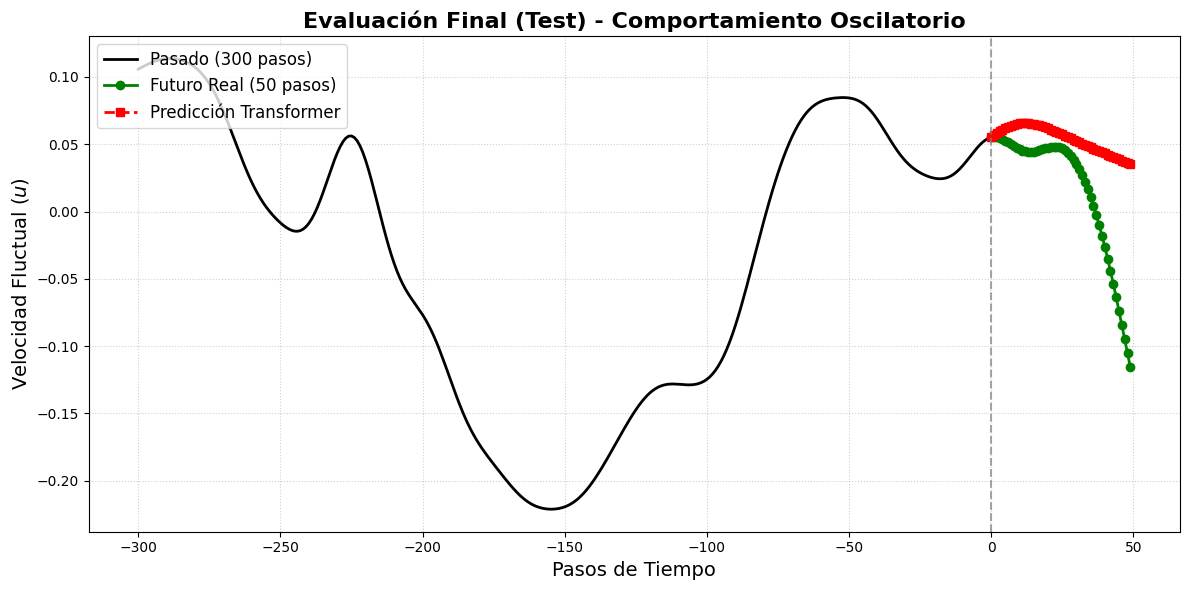

In [5]:
# ==========================================
# 7. EL EXAMEN FINAL (EVALUACIÓN EN TEST)
# ==========================================
import torch
import numpy as np
import matplotlib.pyplot as plt

print("1. Preparando la sala de examen...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recuperamos las estadísticas para desnormalizar luego
media_X = stats_norm['media']
std_X = stats_norm['std']

# 1. CARGAR EL MEJOR MODELO
# Cargamos los pesos del modelo que ganó la estrella roja
checkpoint = torch.load(ruta_mejor_modelo, weights_only=False)
modelo.load_state_dict(checkpoint['model_state_dict'])
modelo.to(device)
modelo.eval() # 🔴 MODO EXAMEN: Cero aprendizaje, cero dropout

print("2. Repartiendo el examen (Procesando Test Loader)...")
predicciones_lista = []
realidades_lista = []

# 2. PASAR TODO EL SET DE TEST
with torch.no_grad():
    for x_test, y_test in test_loader:
        x_test = x_test.to(device)
        
        # Predecimos
        preds = modelo(x_test)
        
        # Guardamos en CPU y NumPy para las matemáticas finales
        predicciones_lista.append(preds.cpu().numpy())
        realidades_lista.append(y_test.numpy())

# Juntamos todos los lotes en matrices gigantes
y_pred_norm = np.concatenate(predicciones_lista, axis=0)
y_real_norm = np.concatenate(realidades_lista, axis=0)

# 3. DESNORMALIZAR (Volver a la física real m/s)
y_pred_real = (y_pred_norm * std_X) + media_X
y_real_real = (y_real_norm * std_X) + media_X

# 4. CALCULAR LAS NOTAS GLOBALES (MÉTRICAS)
mse_test = np.mean((y_real_real - y_pred_real)**2)
rmse_test = np.sqrt(mse_test)
mae_test = np.mean(np.abs(y_real_real - y_pred_real))

print("-" * 40)
print(f"🎓 NOTAS DEL EXAMEN FINAL (Set de Test):")
print(f"   MSE:  {mse_test:.6f}")
print(f"   RMSE: {rmse_test:.4f} m/s")
print(f"   MAE:  {mae_test:.4f} m/s")
print("-" * 40)

# ==========================================
# 5. FOTO FINISH: DIBUJAR UN EJEMPLO DEL EXAMEN
# ==========================================
# Vamos a coger una ventana cualquiera del set de test para ver cómo lo hizo
# Extraemos el primer lote para sacar la historia pasada (x_test)
x_test_muestra, _ = next(iter(test_loader))
pasado_norm = x_test_muestra[0].numpy() # Cogemos el primer ejemplo
pasado_real = (pasado_norm * std_X) + media_X

# Extraemos la predicción y realidad de ese mismo ejemplo
futuro_real = y_real_real[0]
prediccion_ia = y_pred_real[0]

plt.figure(figsize=(12, 6))

# Ejes de tiempo
tiempo_pasado = range(-seq_len, 0)
tiempo_futuro = range(0, pred_len)

# Dibujar
plt.plot(tiempo_pasado, pasado_real, 'k-', label=f'Pasado ({seq_len} pasos)', linewidth=2)
plt.plot(tiempo_futuro, futuro_real, 'g-o', label=f'Futuro Real ({pred_len} pasos)', linewidth=2)
plt.plot(tiempo_futuro, prediccion_ia, 'r--s', label='Predicción Transformer', linewidth=2)

plt.axvline(0, color='gray', linestyle='--', alpha=0.7)
plt.title('Evaluación Final (Test) - Comportamiento Oscilatorio', fontsize=16, fontweight='bold')
plt.xlabel('Pasos de Tiempo', fontsize=14)
plt.ylabel('Velocidad Fluctual ($u$)', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()